P(m,n) – стохастическая матрица перехода
m=1 – 1 декада февраля
n=10 – 1 декада мая

Дискретизируем температуру, разбив шкалу на диапазоны
(всего N диапазонов, не обязательно равных по величине)

Распределения вероятностей:
В векторе π(1) будет единственная 1, остальные 0 – мы точно знаем, какая средняя температура была на первой декаде октября в текущем году

Требуется рассчитать π(10)

Исходные данные – rp5.ru


Задачи:

Вариант 1
π(10) = PT(1,10) x π(1)
Работаем с единой матрицей, заполняемой на основе статистики условных вероятностей перехода между температурными диапазонами первых декад февраля и мая (вся статистика изменений температур на промежуточных декадах не учитывается)

Вариант 2
π(10) = (PT)9 x π(1) – случай однородных цепей Маркова
Работаем с одной и той же матрицей, заполняемой на основе статистики условных вероятностей перехода между температурными диапазонами любой пары соседних декад

Вариант 3
π(10) = PT(9,10) x PT(8,9) x … x PT(3,2) x PT(2,1) x π(1)
Работаем с матрицам, заполняемой на основе статистики условных вероятностей перехода между температурными диапазонами соответствующих пар соседних декад


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# file_path = r'/content/drive/MyDrive/Colab Notebooks/dz_amiimasu/UEEE.26.09.2012.14.03.2026.1.0.0.ru.utf8.00000000.xls'
file_path = Path('UEEE.26.09.2012.14.03.2026.1.0.0.ru.utf8.00000000.xls')

df = pd.read_excel(file_path, header=6)

Расшифровки столбцов по порядку без времени.

'Температура воздуха (градусы Цельсия) на высоте 2 метра над поверхностью земли'

'Атмосферное давление на уровне станции (миллиметры ртутного столба)'

'Атмосферное давление, приведенное к среднему уровню моря (миллиметры ртутного столба)'

'Относительная влажность (%) на высоте 2 метра над поверхностью земли'

'Направление ветра (румбы) на высоте 10-12 метров над земной поверхностью, осредненное за 10-минутный период, непосредственно предшествовавший сроку наблюдения'

'Cкорость ветра на высоте 10-12 метров над земной поверхностью, осредненная за 10-минутный период, непосредственно предшествовавший сроку наблюдения (метры в секунду)'

'Максимальное значение порыва ветра на высоте 10-12 метров над земной поверхностью за 10-минутный период, непосредственно предшествующий сроку наблюдения (метры в секунду)'

'Горизонтальная дальность видимости (км)'

In [17]:
df1 = df.copy()

df1 = df1.drop(columns=df1.columns[2:]).dropna()
df1 = df1.iloc[::-1].reset_index(drop=True)

df1 = df1.rename(columns={"Местное время в Якутске / им. Платона Ойунского (аэропорт)":"datetime"})
df1['datetime'] = pd.to_datetime(df1['datetime'], format='%d.%m.%Y %H:%M')
df1 = df1[((df1['datetime'].dt.hour >= 12) & (df1['datetime'].dt.hour <= 17)) & (df1['datetime'].dt.year != 2026)] # фильтруем промежуток времени дня от 12 до 17:59; убираем 26 год т.к. мало данных

df1['day_of_month'] = df1['datetime'].dt.day
df1['month'] = df1['datetime'].dt.month
df1['day_of_year'] = df1['datetime'].dt.day_of_year
df1['year'] = df1['datetime'].dt.year

def get_decade(day):
    if day <= 10:
        return 1
    elif day <= 20:
        return 2
    else:
        return 3

df1['decade'] = (df1['datetime'].dt.day.apply(get_decade)).astype(int)  # декады

N = 6 # количество диапазонов

ranges = np.linspace(df1['T'].min(), df1['T'].max(), N+1) # равноразмерные диапазоны

print("Диапазоны ", ranges)

df1 = df1.groupby(['year', 'day_of_year', 'day_of_month', 'month', 'decade'], as_index=False)['T'].mean()

df1['range'] = pd.cut(df1['T'], ranges, labels=list(range(1, N+1)))

df1


Диапазоны  [-52.  -37.5 -23.   -8.5   6.   20.5  35. ]


,year,day_of_year,day_of_month,month,decade,T,range
0,2022,163,12,6,2,16.571429,5
1,2022,164,13,6,2,19.083333,5
2,2022,165,14,6,2,17.833333,5
3,2022,166,15,6,2,18.333333,5
4,2022,167,16,6,2,23.916667,6
...,...,...,...,...,...,...,...
1292,2025,361,27,12,3,-43.750000,1
1293,2025,362,28,12,3,-43.750000,1
1294,2025,363,29,12,3,-40.666667,1
1295,2025,364,30,12,3,-43.333333,1


# **Вариант 1**

---



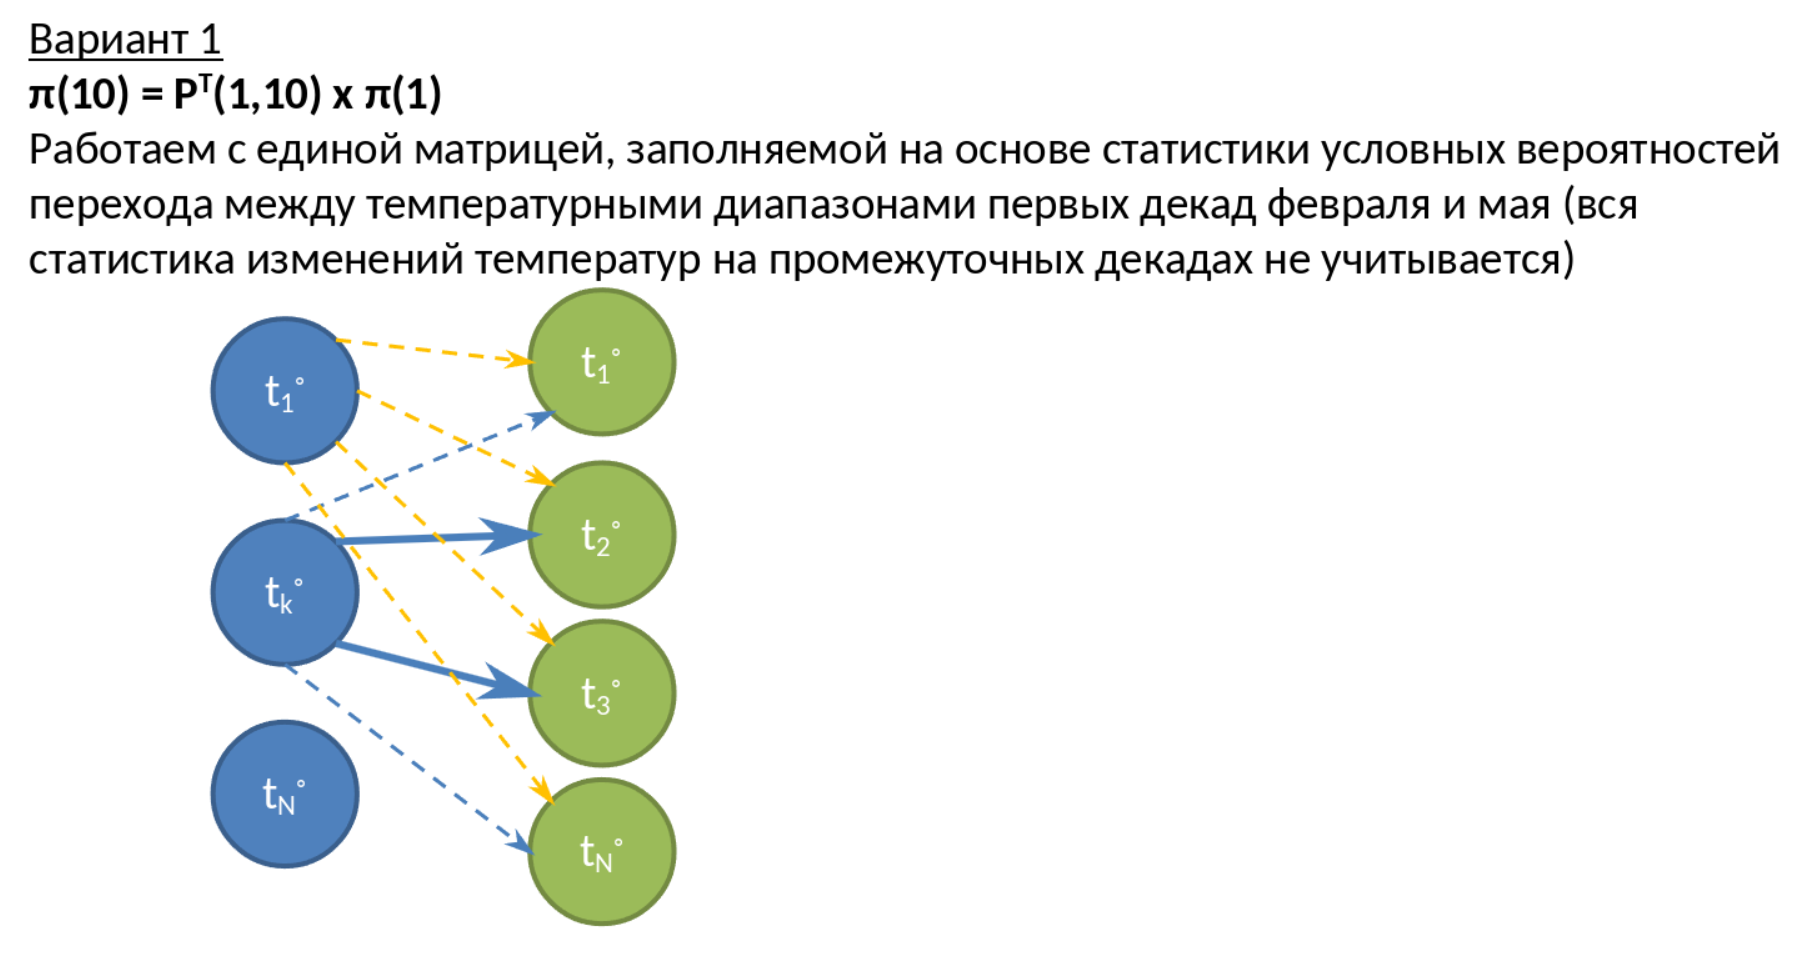

In [18]:
df2 = df1[(df1['decade'] == 1) & ( (df1['month'] == 2) | (df1['month'] == 5) )]

df2 = df2.sort_values(['day_of_month', 'year'])

df2

,year,day_of_year,day_of_month,month,decade,T,range
232,2023,32,1,2,1,-37.750000,1
321,2023,121,1,5,1,11.750000,5
597,2024,32,1,2,1,-29.500000,2
687,2024,122,1,5,1,7.750000,5
963,2025,32,1,2,1,-38.916667,1
1052,2025,121,1,5,1,11.250000,5
233,2023,33,2,2,1,-39.583333,1
322,2023,122,2,5,1,11.500000,5
598,2024,33,2,2,1,-27.500000,2
688,2024,123,2,5,1,8.083333,5


In [19]:
P_1 = np.zeros((N, N))

for i in range( 0, len(df2['range']) - 1):
  if ((df2['month'].iloc[i] == 2) & (df2['month'].iloc[i + 1] == 5) & (df2['year'].iloc[i] == df2['year'].iloc[i + 1])):
    P_1[df2['range'].iloc[i] - 1][df2['range'].iloc[i + 1] - 1] += 1

print(P_1.round(2))
P_1_count = P_1.copy()

# Нормализуем
row_sums = P_1.sum(axis=1)
for i in range(N):
  if row_sums[i] > 0:
    P_1[i] = P_1[i] / row_sums[i]

print()

# Для пустых строк устанавливаем равновероятные переходы
for i in range(N):
  if row_sums[i] == 0:
    P_1[i] = 1/N

print(P_1.round(2))

[[ 0.  0.  0.  4.  7.  0.]
 [ 0.  0.  0.  1. 18.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]]

[[0.   0.   0.   0.36 0.64 0.  ]
 [0.   0.   0.   0.05 0.95 0.  ]
 [0.17 0.17 0.17 0.17 0.17 0.17]
 [0.17 0.17 0.17 0.17 0.17 0.17]
 [0.17 0.17 0.17 0.17 0.17 0.17]
 [0.17 0.17 0.17 0.17 0.17 0.17]]


In [20]:
Pt = P_1.T - np.eye(N)
Pt[-1] = 1
# print(Pt)
Pn = np.linalg.solve( Pt, np.vstack([np.zeros((N-1, 1)), [[1]]]) ) #np.vstack([np.zeros((N-1, 1)), [[1]]])   [[0.], [0.], [0.], [0.], [0.], [1.]]
print("Предельные вероятности\n", Pn, "\n")

print("Матожидание\n", sum(Pn) / N,  "\n")
# print("Матожидание\n", sum(Pn * P_1_count.sum(axis=0).reshape((N, 1)) ),  "\n")

print("Предельная матрица переходов")
PnT = Pn.T
for i in range(2):
    PnT = np.append(PnT, PnT, axis=0)
PnT = np.append(PnT, Pn.T, axis=0)
PnT = np.append(PnT, Pn.T, axis=0)
print(PnT.round(3), "\n")

Предельные вероятности
 [[0.125     ]
 [0.125     ]
 [0.125     ]
 [0.17703349]
 [0.32296651]
 [0.125     ]] 

Матожидание
 [0.16666667] 

Предельная матрица переходов
[[0.125 0.125 0.125 0.177 0.323 0.125]
 [0.125 0.125 0.125 0.177 0.323 0.125]
 [0.125 0.125 0.125 0.177 0.323 0.125]
 [0.125 0.125 0.125 0.177 0.323 0.125]
 [0.125 0.125 0.125 0.177 0.323 0.125]
 [0.125 0.125 0.125 0.177 0.323 0.125]] 



---

# **Вариант 2**

---

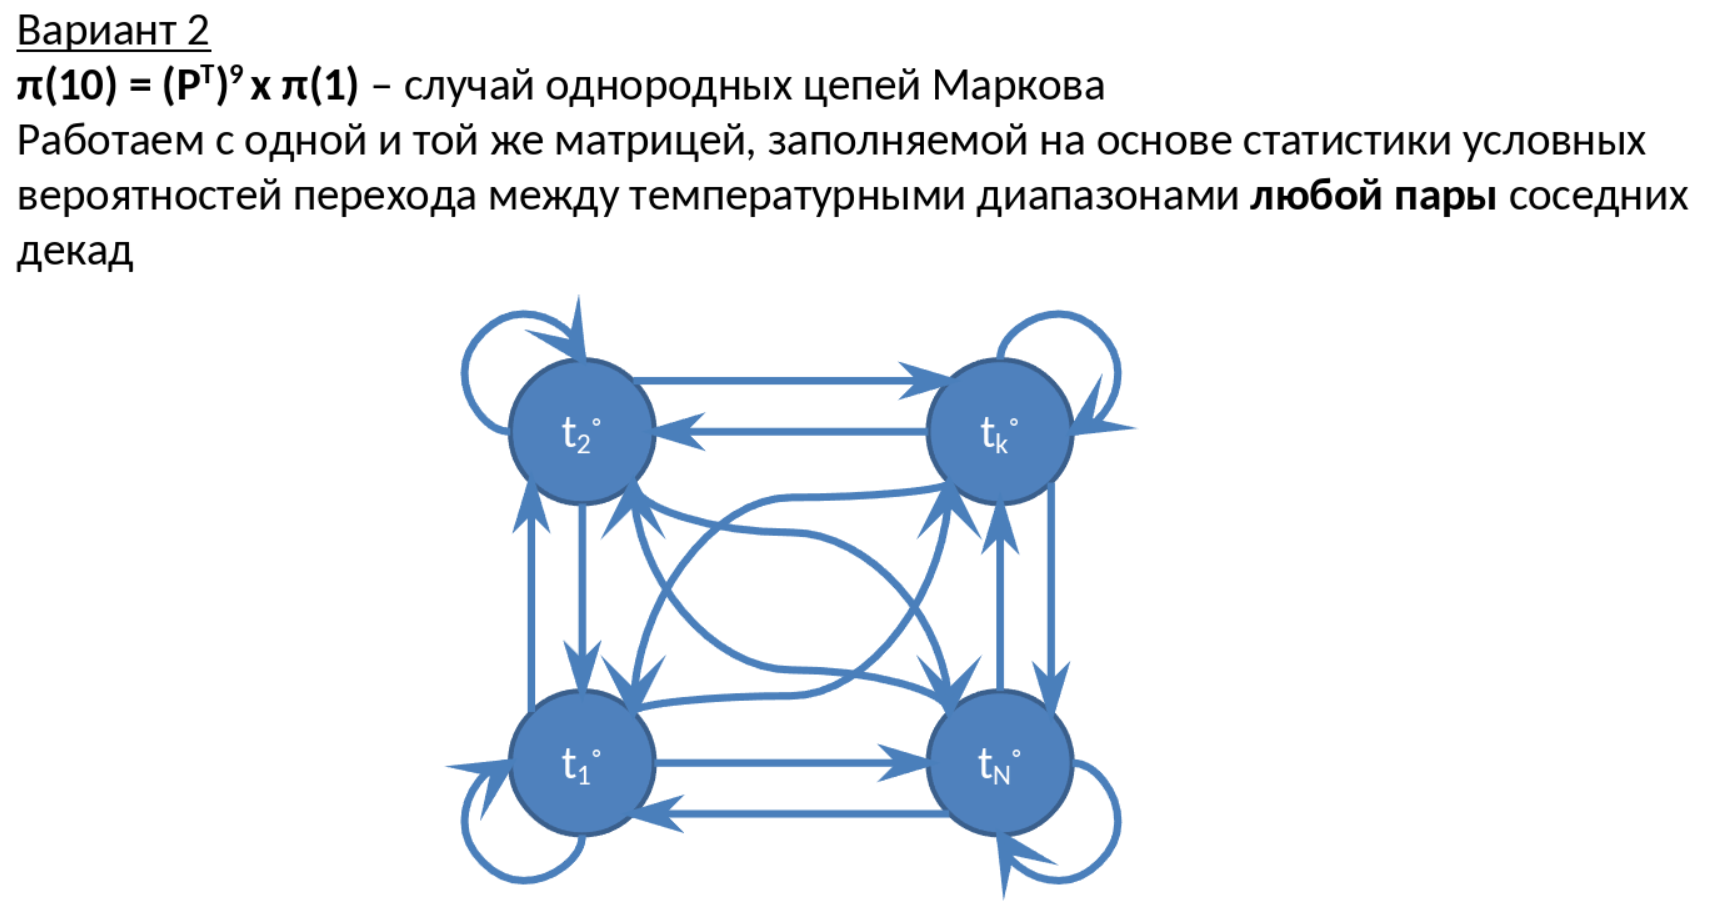

In [21]:
df3 = df1.sort_values(['year', 'month'])

df3

,year,day_of_year,day_of_month,month,decade,T,range
0,2022,163,12,6,2,16.571429,5
1,2022,164,13,6,2,19.083333,5
2,2022,165,14,6,2,17.833333,5
3,2022,166,15,6,2,18.333333,5
4,2022,167,16,6,2,23.916667,6
...,...,...,...,...,...,...,...
1292,2025,361,27,12,3,-43.750000,1
1293,2025,362,28,12,3,-43.750000,1
1294,2025,363,29,12,3,-40.666667,1
1295,2025,364,30,12,3,-43.333333,1


In [22]:
P_2 = np.zeros((N, N))

for i in range( len(df3['range']) - 1):
  if ( (abs(df3['decade'].iloc[i] - df3['decade'].iloc[i + 1]) == 1) ):
    P_2[df3['range'][i] - 1][df3['range'][i + 1] - 1] += 1

print(P_2.round(2))
P_2_count = P_2.copy()


# Нормализуем
row_sums = P_2.sum(axis=1)
for i in range(N):
  if row_sums[i] > 0:
    P_2[i] = P_2[i] / row_sums[i]

print()

# Для пустых строк устанавливаем равновероятные переходы
for i in range(N):
  if row_sums[i] == 0:
    P_2[i] = 1/N

print(P_2.round(2))

[[ 6.  4.  0.  0.  0.  0.]
 [ 3.  7.  1.  0.  0.  0.]
 [ 0.  3.  9.  0.  0.  0.]
 [ 0.  0.  2. 12.  2.  0.]
 [ 0.  0.  0.  3. 14.  5.]
 [ 0.  0.  0.  0.  2. 12.]]

[[0.6  0.4  0.   0.   0.   0.  ]
 [0.27 0.64 0.09 0.   0.   0.  ]
 [0.   0.25 0.75 0.   0.   0.  ]
 [0.   0.   0.12 0.75 0.12 0.  ]
 [0.   0.   0.   0.14 0.64 0.23]
 [0.   0.   0.   0.   0.14 0.86]]


In [23]:
P_2 = P_2 @ P_2 @ P_2 @ P_2 @ P_2 @ P_2 @ P_2 @ P_2 @ P_2 @ P_2

Pt = P_2.T - np.eye(N)
Pt[-1] = 1

Pn = np.linalg.solve( Pt, np.vstack([np.zeros((N - 1, 1)), [[1]]]) )
print("Предельные вероятности\n", Pn, "\n")
print("Матожидание\n", sum(Pn) / N,  "\n")
print("Предельная матрица переходов")
PnT = Pn.T
for i in range(2):
    PnT = np.append(PnT, PnT, axis=0)
PnT = np.append(PnT, Pn.T, axis=0)
PnT = np.append(PnT, Pn.T, axis=0)
print(PnT.round(3), "\n")

Предельные вероятности
 [[3.33333333e-01]
 [4.88888889e-01]
 [1.77777778e-01]
 [8.76261800e-17]
 [1.51687697e-16]
 [3.98738323e-16]] 

Матожидание
 [0.16666667] 

Предельная матрица переходов
[[0.333 0.489 0.178 0.    0.    0.   ]
 [0.333 0.489 0.178 0.    0.    0.   ]
 [0.333 0.489 0.178 0.    0.    0.   ]
 [0.333 0.489 0.178 0.    0.    0.   ]
 [0.333 0.489 0.178 0.    0.    0.   ]
 [0.333 0.489 0.178 0.    0.    0.   ]] 



---

# **Вариант 3**

---

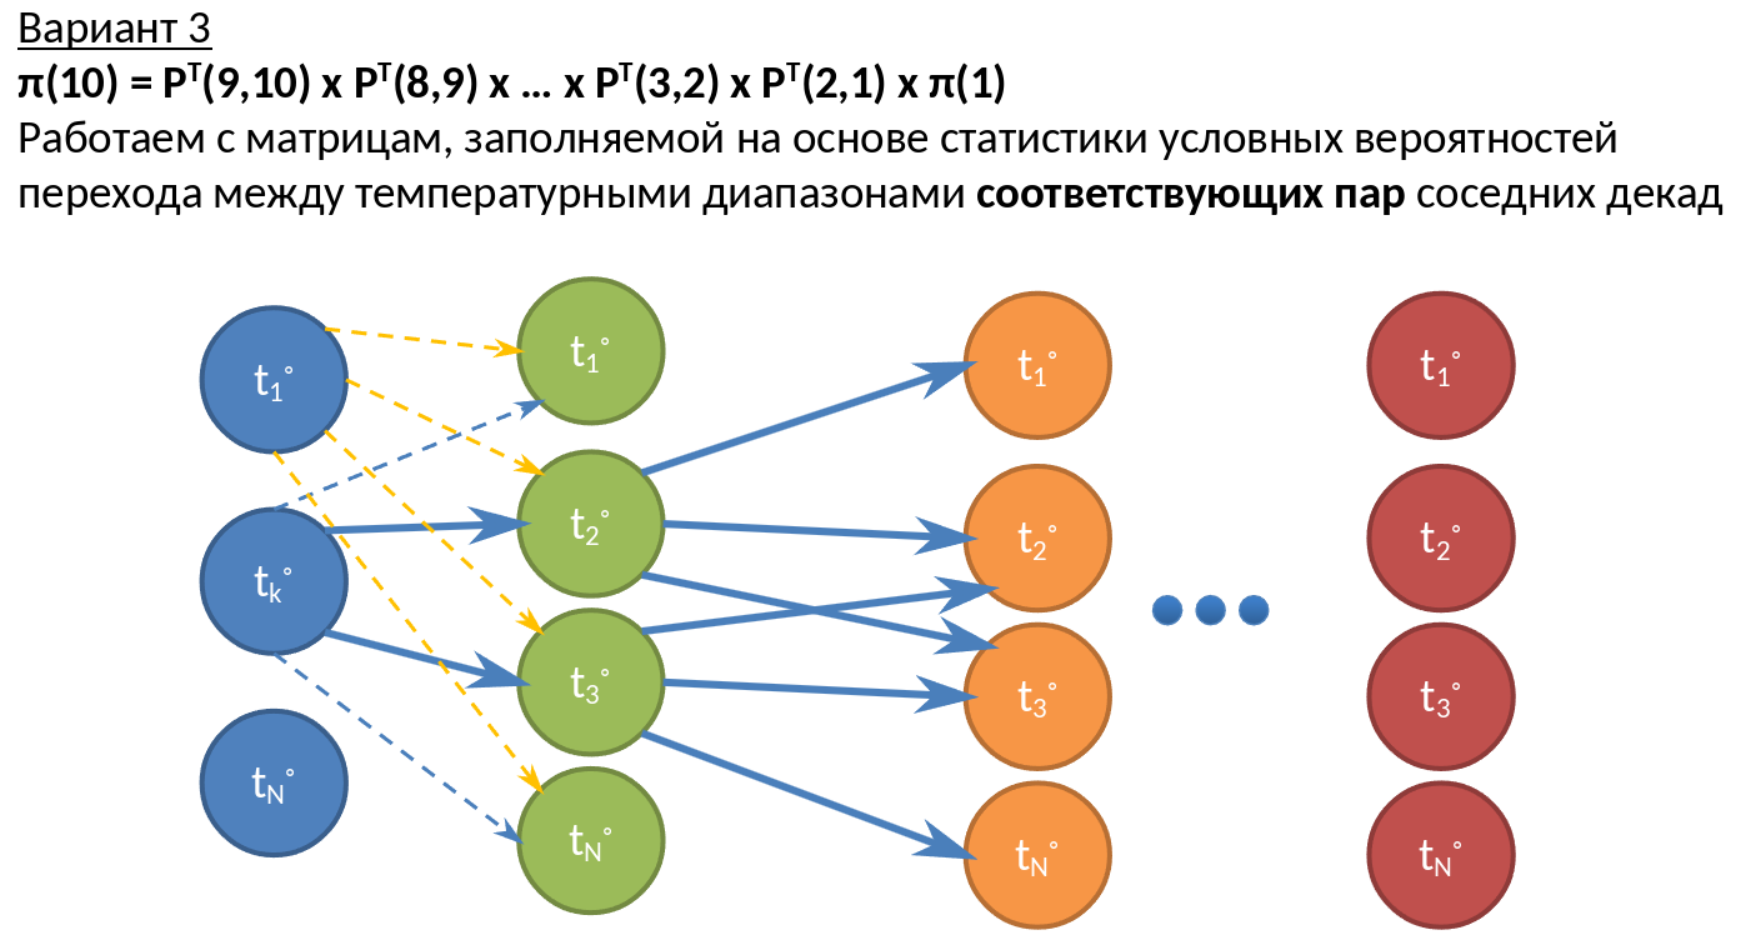

In [24]:
df4 = df1.sort_values(['year', 'day_of_month','month', 'decade'])
df4= df4.dropna().astype(int)
df4

,year,day_of_year,day_of_month,month,decade,T,range
19,2022,182,1,7,1,26,6
48,2022,213,1,8,1,28,6
79,2022,244,1,9,1,8,5
109,2022,274,1,10,1,-1,4
140,2022,305,1,11,1,-9,3
...,...,...,...,...,...,...,...
1082,2025,151,31,5,3,8,5
1143,2025,212,31,7,3,20,5
1174,2025,243,31,8,3,19,5
1235,2025,304,31,10,3,-11,3


In [26]:
P_3_matrices = np.zeros((100, N, N))
P_3_matrices_count = np.zeros((11, N, N))

df4 = df4[(df4['month'] >= 2) & (df4['month'] <= 5)]

k = 0
for dec in range(1, 4):
  print("Декада -", dec)
  for month in range(df4['month'].min(), df4['month'].max()):
    print("Месяцы -", month, month + 1)
    df4_ = df4[((df4['month'] == month) | (df4['month'] == month + 1)) & (df4['decade'] == dec)]
    # print(df4_)
    for i in range( len(df4_['range']) - 1):
      if ( (df4_['decade'].iloc[i] == df4_['decade'].iloc[i + 1]) & (df4_['year'].iloc[i] == df4_['year'].iloc[i + 1])
          & ( abs(df4_['month'].iloc[i] - df4_['month'].iloc[i + 1]) == 1)):
          P_3_matrices[k][df4_['range'].iloc[i] - 1][df4_['range'].iloc[i + 1] - 1] += 1
    print(f'Номер пары - {k + 1}\n', P_3_matrices[k])
    P_3_matrices_count[k] = P_3_matrices[k].copy()

    # Нормализуем
    row_sums = P_3_matrices[k].sum(axis=1)
    for i in range(N):
      if row_sums[i] > 0:
        P_3_matrices[k][i] = P_3_matrices[k][i] / row_sums[i]

    # Для пустых строк устанавливаем равновероятные переходы
    for i in range(N):
      if row_sums[i] == 0:
        P_3_matrices[k][i] = 1/N

    print(P_3_matrices[k])
    k+=1





Декада - 1
Месяцы - 2 3
Номер пары - 1
 [[ 0.  3.  8.  0.  0.  0.]
 [ 1. 20. 10.  0.  0.  0.]
 [ 8.  7.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]]
[[0.         0.27272727 0.72727273 0.         0.         0.        ]
 [0.03225806 0.64516129 0.32258065 0.         0.         0.        ]
 [0.53333333 0.46666667 0.         0.         0.         0.        ]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
Месяцы - 3 4
Номер пары - 2
 [[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  2. 10.  0.  0.]
 [ 0.  2.  2. 17.  0.  0.]
 [ 0.  7. 17.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]]
[[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.         0.         0.16666667 0.83333333 0.         0.        ]
 [0.         0.0952381  0.0952381  0.80952381 0.    

In [27]:
P_big = P_3_matrices[0].copy()
for i in range(1, k):
  # print(P_big, i)
  P_big = P_big @ P_3_matrices[i]
print(P_big)

Pt = P_big.T - np.eye(N)
Pt[-1] = 1
Pn = np.linalg.solve( Pt, np.vstack([np.zeros((N - 1, 1)), [[1]]]) ) #np.vstack([np.zeros((N-1, 1)), [[1]]])
print("Предельные вероятности\n", Pn, "\n")

print("Матожидание\n", sum(Pn) / N, "\n")

print("Предельная матрица переходов")
PnT = Pn.T
for i in range(2):
    PnT = np.append(PnT, PnT, axis=0)
PnT = np.append(PnT, Pn.T, axis=0)
print(PnT.round(3), "\n")

[[0.05238702 0.05238702 0.05238702 0.20577553 0.43526515 0.20179824]
 [0.05236827 0.05236827 0.05236827 0.20576028 0.43531684 0.20181808]
 [0.05255652 0.05255652 0.05255652 0.2059144  0.43479767 0.20161837]
 [0.0526376  0.0526376  0.0526376  0.20596581 0.43458011 0.20154128]
 [0.0526376  0.0526376  0.0526376  0.20596581 0.43458011 0.20154128]
 [0.0526376  0.0526376  0.0526376  0.20596581 0.43458011 0.20154128]]
Предельные вероятности
 [[0.05260598]
 [0.05260598]
 [0.05260598]
 [0.20594229]
 [0.43466635]
 [0.20157341]] 

Матожидание
 [0.16666667] 

Предельная матрица переходов
[[0.053 0.053 0.053 0.206 0.435 0.202]
 [0.053 0.053 0.053 0.206 0.435 0.202]
 [0.053 0.053 0.053 0.206 0.435 0.202]
 [0.053 0.053 0.053 0.206 0.435 0.202]
 [0.053 0.053 0.053 0.206 0.435 0.202]] 



---
